# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [60]:
# untuk plot Q-Q
import scipy.stats as stats

In [61]:
pwd

'/content'

In [62]:
df_california = pd.read_csv('california_dataset.csv')

In [63]:
from sklearn.model_selection import train_test_split
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state=42)
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

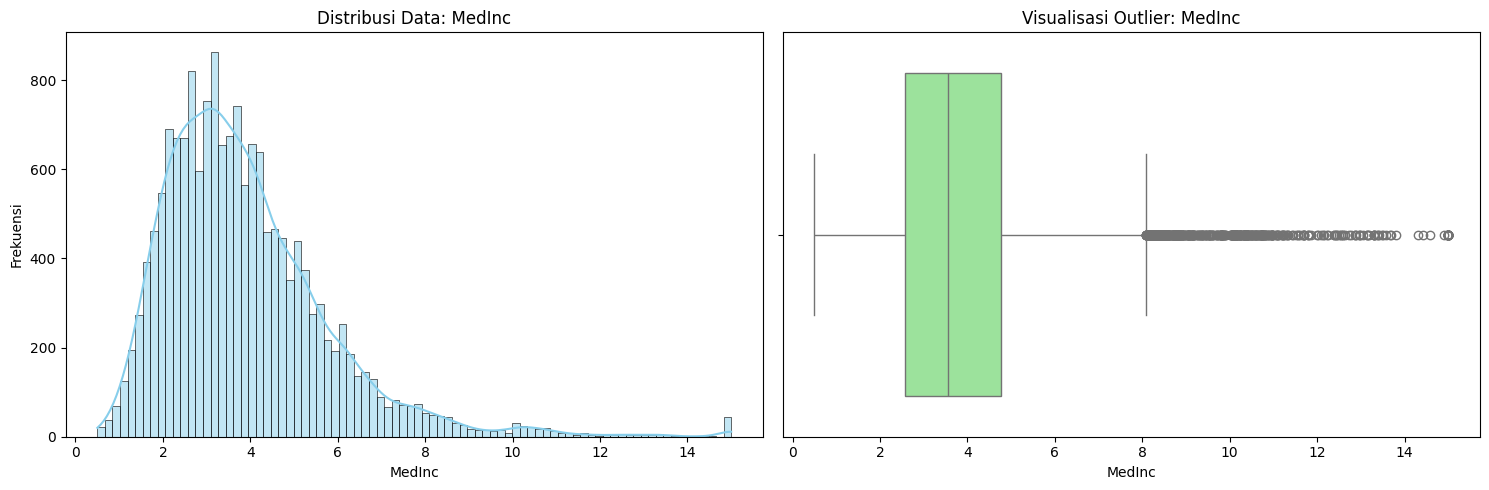

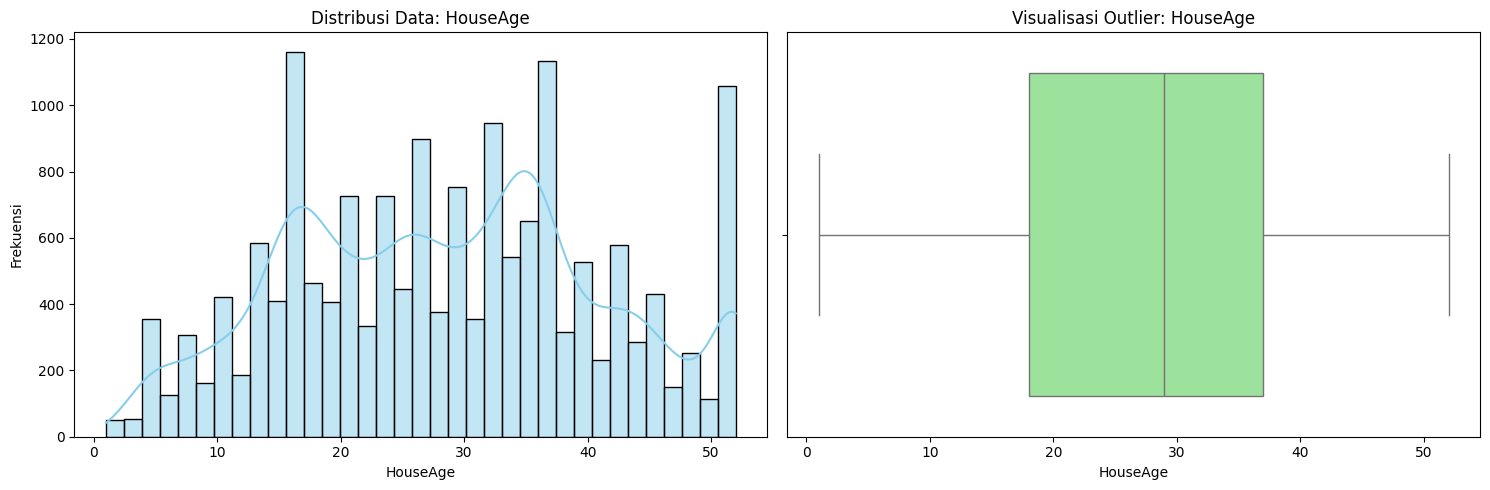

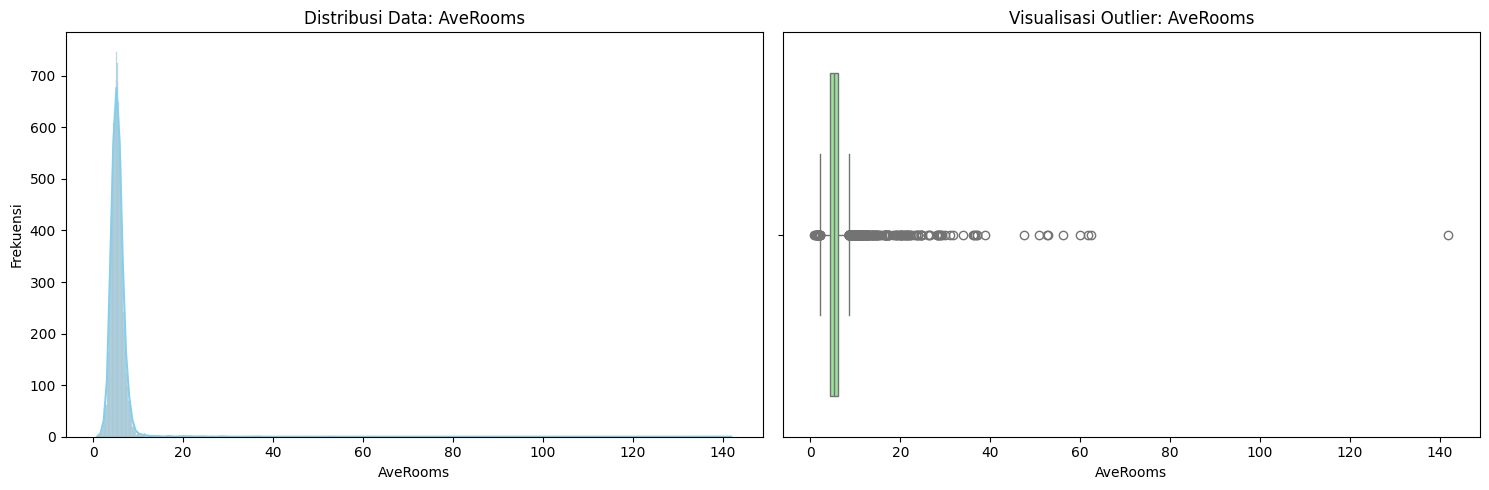

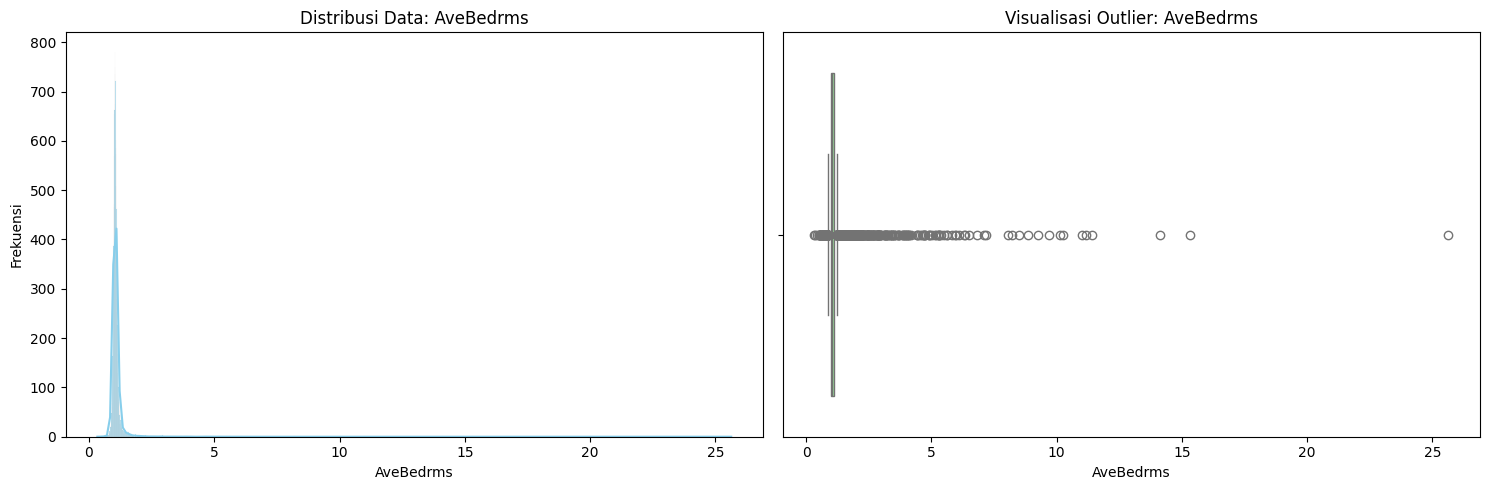

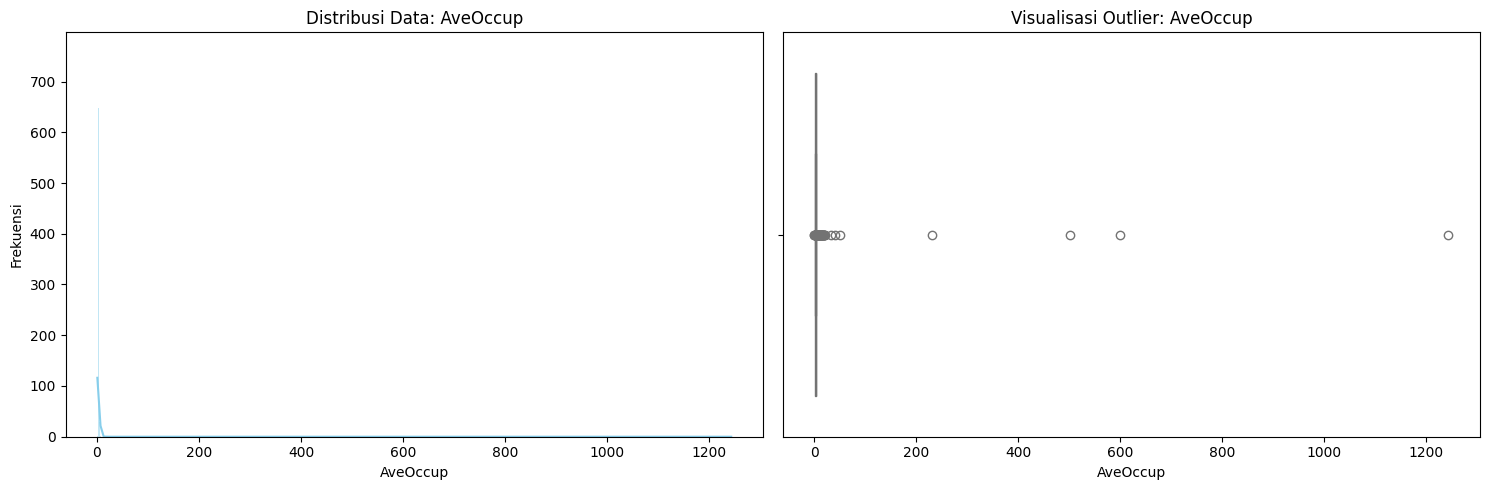

In [64]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek

# Daftar kolom yang ingin di cek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# Melakukan loop
for col in kolom_kolom:
    # Membuat figure dengan 2 subplot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Menggunakan train_clfr sesuai konteks bahwa analisis dilakukan pada data latih
    sns.histplot(train_clfr[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribusi Data: {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frekuensi')

    # 2. Plot Deteksi Outlier (Boxplot) di sebelah kanan
    sns.boxplot(x=train_clfr[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Visualisasi Outlier: {col}')
    axes[1].set_xlabel(col)

    # Merapikan dan menampilkan data
    plt.tight_layout()
    plt.show()


### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

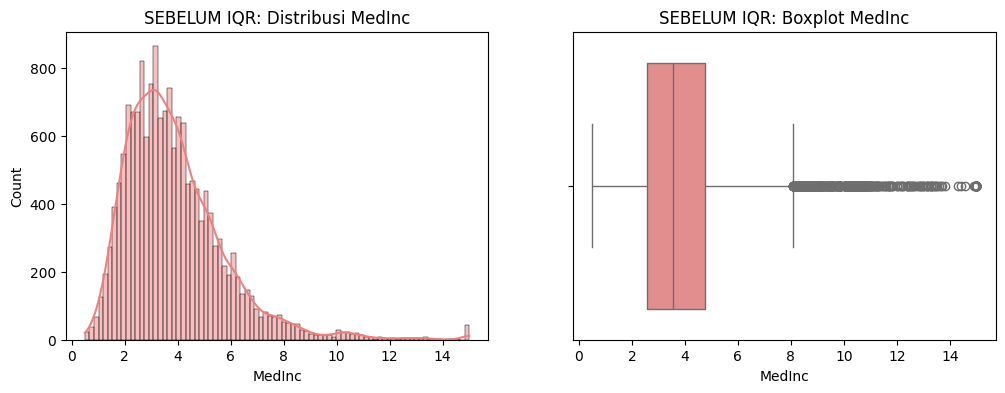

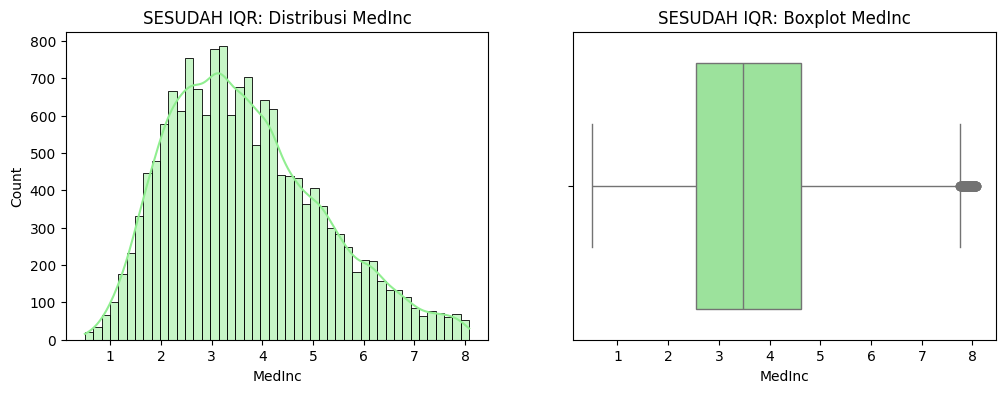

In [65]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
kolom_pilihan = 'MedInc'

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(train_clfr[kolom_pilihan], kde=True, color='lightcoral')
plt.title(f'SEBELUM IQR: Distribusi {kolom_pilihan}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_clfr[kolom_pilihan], color='lightcoral')
plt.title(f'SEBELUM IQR: Boxplot {kolom_pilihan}')
plt.show()


Q1 = train_clfr[kolom_pilihan].quantile(0.25)
Q3 = train_clfr[kolom_pilihan].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

train_clfr_clean = train_clfr[
    (train_clfr[kolom_pilihan] >= batas_bawah) &
    (train_clfr[kolom_pilihan] <= batas_atas)
].copy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(train_clfr_clean[kolom_pilihan], kde=True, color='lightgreen')
plt.title(f'SESUDAH IQR: Distribusi {kolom_pilihan}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_clfr_clean[kolom_pilihan], color='lightgreen')
plt.title(f'SESUDAH IQR: Boxplot {kolom_pilihan}')
plt.show()

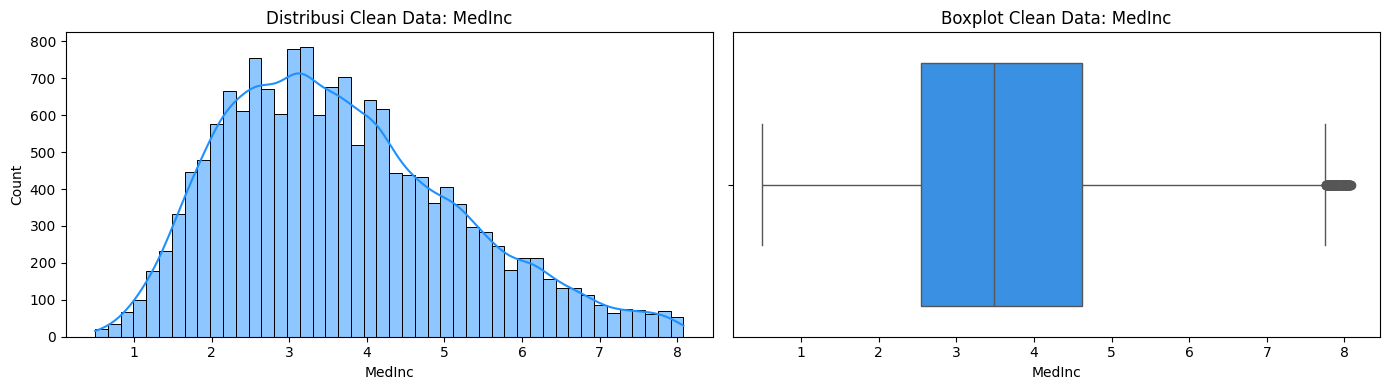

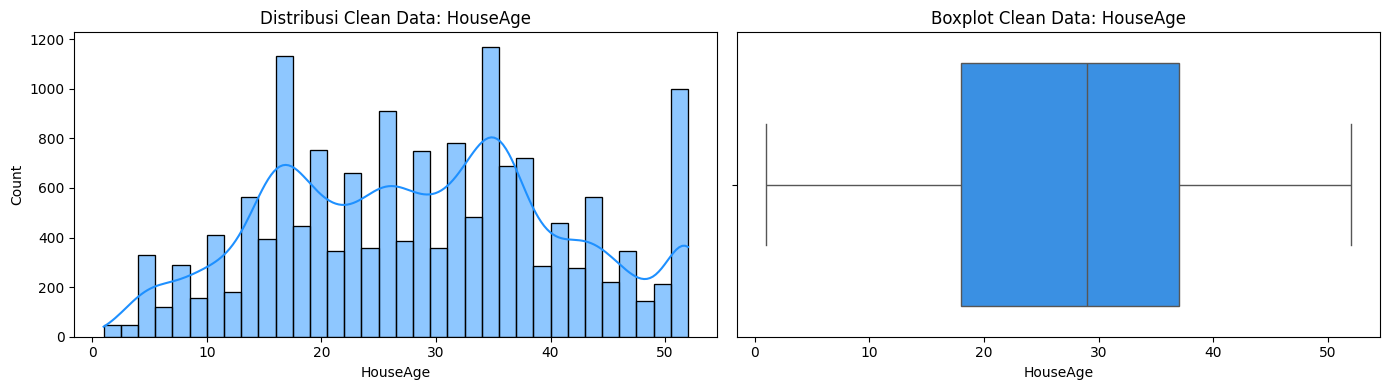

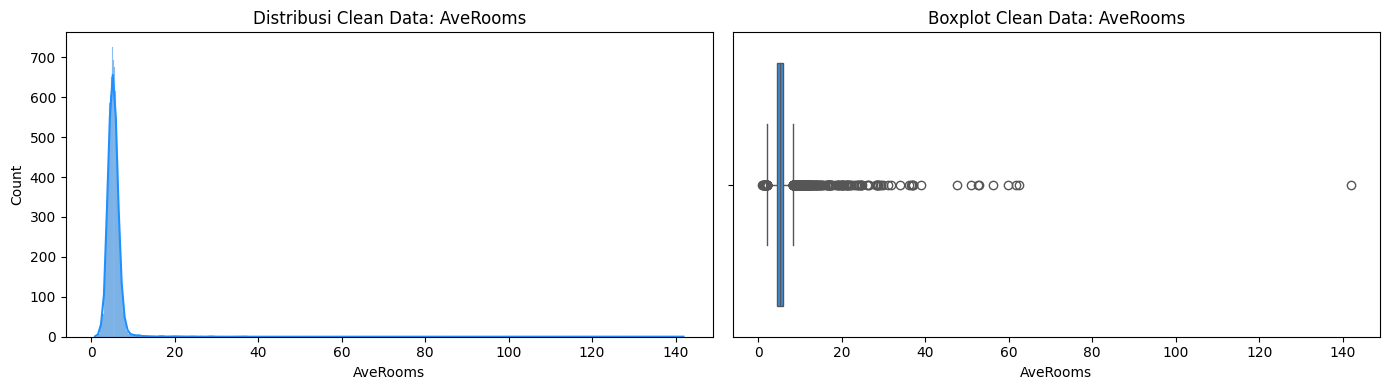

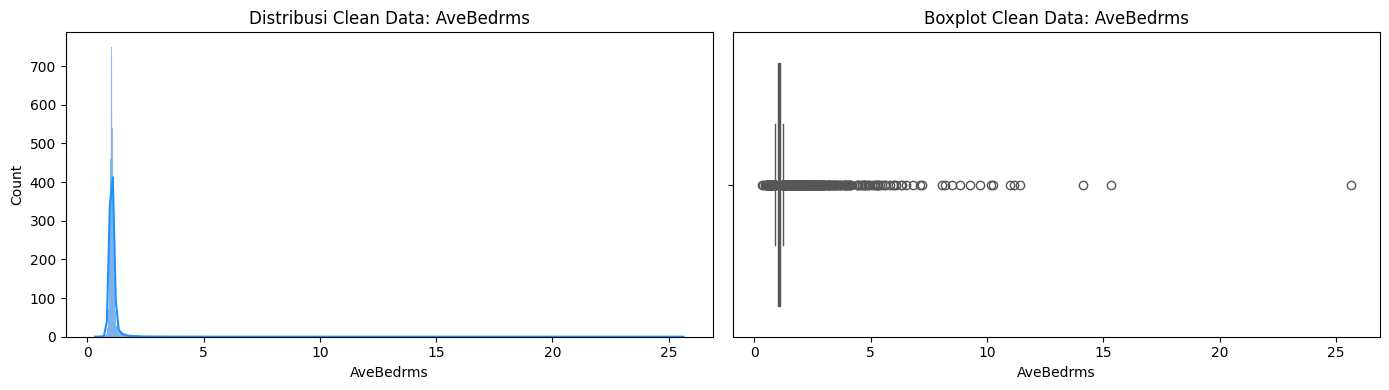

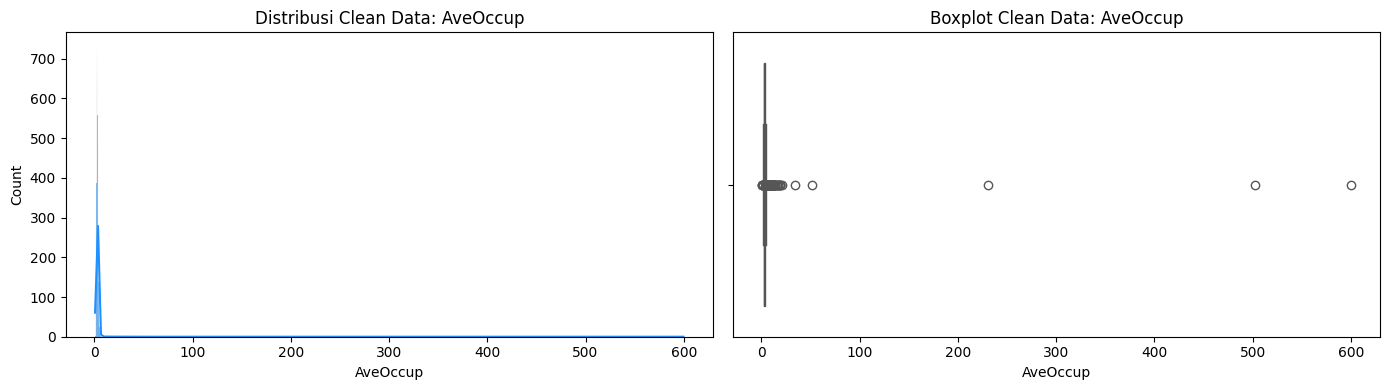

In [66]:
# Melakukan loop untuk mengecek distribusi tiap kolom
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# Melakukan loop pada dataset
for col in kolom_kolom:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(train_clfr_clean[col], kde=True, ax=axes[0], color='dodgerblue')
    axes[0].set_title(f'Distribusi Clean Data: {col}')

    sns.boxplot(x=train_clfr_clean[col], ax=axes[1], color='dodgerblue')
    axes[1].set_title(f'Boxplot Clean Data: {col}')

    plt.tight_layout()
    plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [67]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [68]:
from sklearn.model_selection import train_test_split
train_company, test_company = train_test_split(df_company, test_size=0.2, random_state=42)
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

In [69]:
mode_size_train = train_company[~train_company['Size'].isin(['-1', 'Unknown'])]['Size'].mode()[0]

In [70]:
train_company['Size'] = train_company['Size'].apply(lambda x: mode_size_train if x in ['-1', 'Unknown'] else x)
test_company['Size'] = test_company['Size'].apply(lambda x: mode_size_train if x in ['-1', 'Unknown'] else x)

print("\nSisa data rusak (-1 atau Unknown) di train_company:", len(train_company[train_company['Size'].isin(['-1', 'Unknown'])]))


Sisa data rusak (-1 atau Unknown) di train_company: 0


## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [71]:
#Tulis jawaban missing value handling kolom Headquarters disini
# =================================================================================
display(df_company['Headquarters'].value_counts().head())

missing_hq = len(df_company[df_company['Headquarters'].isin(['-1', 'Unknown'])])
persentase_hq = 100 * missing_hq / len(df_company)

print(f"\nPersentase missing value Headquarters: {persentase_hq:.2f}%")

#KEPUTUSAN DROP ATAU HANDLING (Menggunakan Modus)
if persentase_hq > 20:
    print("Keputusan: DROP KOLOM")
    print("Alasan: Persentase missing value melebihi batas toleransi 20%.")
else:
    print("Keputusan: TIDAK DI-DROP (Melakukan Handling menggunakan MODUS)")
    mode_hq_train = train_company[~train_company['Headquarters'].isin(['-1', 'Unknown'])]['Headquarters'].mode()[0]
    print(f"Bukti Modus Headquarters yang akan disuntikkan: '{mode_hq_train}'")

    train_company['Headquarters'] = train_company['Headquarters'].apply(lambda x: mode_hq_train if x in ['-1', 'Unknown'] else x)
    test_company['Headquarters'] = test_company['Headquarters'].apply(lambda x: mode_hq_train if x in ['-1', 'Unknown'] else x)

    # Validasi Akhir
    sisa_rusak = len(train_company[train_company['Headquarters'].isin(['-1', 'Unknown'])])
    print(f"Status Handling: Selesai. Sisa data rusak di train_company: {sisa_rusak}")


,count
Headquarters,
"New York, NY",33
"San Francisco, CA",31
-1,31
"Chicago, IL",23
"Boston, MA",19



Persentase missing value Headquarters: 4.61%
Keputusan: TIDAK DI-DROP (Melakukan Handling menggunakan MODUS)
Bukti Modus Headquarters yang akan disuntikkan: 'New York, NY'
Status Handling: Selesai. Sisa data rusak di train_company: 0


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [72]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [73]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

df_churn['Churn'] = df_churn['Churn'].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False)
df_churn['Churn'] = df_churn['Churn'].replace({'Yes': 1, 'No': 0})

kolom_layanan = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity']
for col in kolom_layanan:
    df_churn[col] = df_churn[col].replace({'No internet service': 'No'})

df_churn['MultipleLines'] = df_churn['MultipleLines'].replace({'No phone service': 'No'})

train_churn, test_churn = train_test_split(df_churn, test_size=0.2, random_state=42)

print(f"Data latih siap: {len(train_churn)} baris")
print(f"Data uji siap : {len(test_churn)} baris")

Data latih siap: 5634 baris
Data uji siap : 1409 baris


In [74]:
#Splitting terlebih dahulu
from sklearn.model_selection import train_test_split

# Melakukan Splitting 80:20 terlebih dahulu sebelum Encoding
train_churn, test_churn = train_test_split(df_churn, test_size=0.2, random_state=42)


In [75]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

encode_ohe = ['gender']
train_churn = pd.get_dummies(train_churn, columns=encode_ohe, dtype=int)
test_churn = pd.get_dummies(test_churn, columns=encode_ohe, dtype=int)

columns_to_encode = ['Partner', 'Dependents']
label_encoder = LabelEncoder()

for col in columns_to_encode:
    train_churn[col] = label_encoder.fit_transform(train_churn[col])
    test_churn[col] = label_encoder.transform(test_churn[col])

mean_contract = train_churn.groupby('Contract')['Churn'].mean()

print("--- Nilai Probabilitas Churn per Tipe Kontrak ---")
print(mean_contract)
print("-" * 50)

# Memetakan (mapping) nilai probabilitas tersebut ke data train dan test
train_churn['Contract'] = train_churn['Contract'].map(mean_contract)
test_churn['Contract'] = test_churn['Contract'].map(mean_contract)

print("\n=== Validasi Data Train Setelah 3 Proses Encoding ===")
display(train_churn[['gender_Female', 'gender_Male', 'Partner', 'Dependents', 'Contract', 'Churn']].head())

--- Nilai Probabilitas Churn per Tipe Kontrak ---
Contract
Month-to-month    0.426533
One year          0.117987
Two year          0.028379
Name: Churn, dtype: float64
--------------------------------------------------

=== Validasi Data Train Setelah 3 Proses Encoding ===


,gender_Female,gender_Male,Partner,Dependents,Contract,Churn
2142,1,0,0,1,0.117987,0
1623,1,0,0,0,0.028379,0
6074,0,1,1,0,0.426533,1
1362,0,1,0,0,0.426533,1
6754,0,1,0,1,0.028379,0


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [76]:

df_churn = pd.read_csv('TelcoCustomerChurn.csv')

kolom_tugas = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

for col in kolom_tugas:
    if col == 'MultipleLines':
        df_churn[col] = df_churn[col].replace({'No phone service': 'No'})
    else:
        df_churn[col] = df_churn[col].replace({'No internet service': 'No'})

print("BUKTI VALIDASI SEBELUM ENCODING")
for col in kolom_tugas:
    print(f"--- Kolom: {col} ---")
    print(df_churn[col].value_counts())
    print()

train_churn, test_churn = train_test_split(df_churn, test_size=0.2, random_state=42)

le = LabelEncoder()
for col in kolom_tugas:
    train_churn[col] = le.fit_transform(train_churn[col])
    test_churn[col] = le.transform(test_churn[col])

display(train_churn[kolom_tugas].head())

BUKTI VALIDASI SEBELUM ENCODING
--- Kolom: StreamingMovies ---
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64

--- Kolom: StreamingTV ---
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64

--- Kolom: TechSupport ---
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64

--- Kolom: DeviceProtection ---
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64

--- Kolom: OnlineBackup ---
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64

--- Kolom: OnlineSecurity ---
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64

--- Kolom: MultipleLines ---
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64



,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
2142,1,0,0,1,0,1,0
1623,1,1,0,0,1,0,1
6074,0,0,0,0,0,0,0
1362,0,0,0,0,0,0,0
6754,0,0,1,0,1,1,1


## Selesai :)